# 1. 랭그래프란 어떤 프레임워크인가

## **랭그래프란?**

랭그래프는 LangChain 생태계에서 개발된 그래프 기반 워크플로우 프레임워크로, 복잡한 멀티 에이전트 시스템과 상태 기반 AI 애플리케이션을 개발하는 데 특화되어 있다. 기존의 선형적인 처리 방식과 달리, 노드(점)와 엣지(선)로 구성된 그래프 구조를 통해 비선형적이고 동적인 프로세스를 구성할 수 있다.

랭그래프의 가장 큰 특징은 **사이클(순환 구조)**을 지원한다는 점이다4. 이는 특정 조건에 따라 이전 단계로 돌아가거나 다른 경로를 선택할 수 있음을 의미한다. 예를 들어, 검색 결과가 만족스럽지 않을 때 다시 검색을 수행하거나, 답변의 품질이 낮을 때 재생성을 요청하는 등의 복잡한 로직을 구현할 수 있다.

## **랭체인과의 관계**

랭그래프는 랭체인(LangChain)의 기능을 확장하여 만들어진 프레임워크이다. 두 프레임워크의 주요 차이점을 살펴보면 다음과 같다:

**구조적 차이점:**

- **랭체인**: 선형적이고 직선적인 체인 구조로, 정의된 순서에 따라 작업을 수행한다
    
- **랭그래프**: 노드와 엣지의 연결을 통해 비선형적이고 동적인 프로세스를 구성한다
    

**복잡도와 유연성:**

- **랭체인**: 비교적 간단한 애플리케이션과 직선적인 워크플로우에 적합하다
    
- **랭그래프**: 복잡한 다단계 작업, 멀티 에이전트 협업, 동적인 의사결정 트리 등 복잡한 워크플로우를 관리하는 데 유용하다
    

**상태 관리:**

- **랭체인**: 암시적이고 자동화된 상태 관리를 제공한다
    
- **랭그래프**: 명시적이고 세밀한 상태 관리를 통해 각 단계에서 상태를 직접 제어할 수 있다
    

## **랭그래프 프레임워크의 핵심 기능 정리**

랭그래프의 핵심 기능들을 정리하면 다음과 같다:

**1. 그래프 기반 워크플로우**: 노드와 엣지로 구성된 그래프 구조를 통해 복잡한 처리 흐름을 시각적으로 표현하고 관리할 수 있다.

**2. 상태 기반 처리**: 전체 애플리케이션의 상태를 중앙에서 관리하며, 각 노드가 이 상태를 공유하고 업데이트할 수 있다4.

**3. 조건부 분기**: 실행 중에 조건에 따라 다른 경로를 선택할 수 있는 동적 라우팅 기능을 제공한다.

**4. 순환 구조 지원**: 특정 조건에서 이전 단계로 돌아가거나 반복 실행이 가능한 사이클 구조를 구현할 수 있다4.

**5. 멀티 에이전트 협업**: 여러 AI 에이전트가 협력하여 복잡한 작업을 수행할 수 있는 환경을 제공한다.


# 2. 랭그래프 기본 구조

## **엣지와 노드**

랭그래프의 기본 구조는 **노드(Node)** 와 **엣지(Edge)** 로 구성된다.

**노드(Node)**: 실제 작업을 수행하는 Python 함수들로, 각각의 노드는 특정 로직을 담당한다. 노드는 현재 상태를 입력으로 받아서 작업을 수행하고, 업데이트된 상태를 반환한다. 예를 들어, LLM 호출, 문서 검색, 데이터 처리 등의 기능을 수행할 수 있다.

**엣지(Edge)**: 노드 간의 연결을 정의하며, 다음에 어떤 노드를 실행할지 결정하는 역할을 한다. 엣지는 워크플로우의 흐름을 제어하고 조건부 라우팅을 가능하게 한다.

## **상태(State)**

상태(State)는 전체 애플리케이션의 현재 상태를 나타내는 공유 데이터 구조이다. 모든 노드가 이 상태에 접근할 수 있으며, 작업 결과에 따라 상태를 업데이트할 수 있다. 상태는 일반적으로 TypedDict 또는 Pydantic BaseModel로 정의된다.

상태의 주요 역할은 다음과 같다:

- **전체 워크플로우의 컨텍스트 유지**: 처리 과정에서 필요한 모든 정보를 중앙에서 관리한다
    
- **노드 간 정보 공유**: 한 노드에서 처리한 결과를 다른 노드에서 활용할 수 있게 한다
    
- **진행 상황 추적**: 현재 어떤 단계에 있는지, 어떤 작업이 완료되었는지 추적한다
    

## **StateGraph**

StateGraph는 랭그래프의 핵심 클래스로, 상태 기반의 계산 그래프를 정의하는 역할을 한다. StateGraph는 에이전트의 수명 주기 전반에 걸쳐 상태가 유지되도록 하며, 그래프의 노드들이 이 상태를 업데이트할 수 있게 한다.

StateGraph의 초기화 과정에서는 상태 정의를 전달하며, 이후 노드들이 키-값 형태로 상태의 속성을 반환하게 된다.

## **랭그래프에서 상태관리**

랭그래프에서 상태 관리는 두 가지 방식으로 이루어진다:

**1. 완전 재정의 방식**: 노드가 속성의 새 값을 반환하여 기존 값을 **완전히 대체**하는 방식이다.

**2. 업데이트 방식**: 기존 속성 값에 **새로운 값을 추가**하는 방식으로, `operator.add`와 같은 어노테이션을 사용하여 구현한다. 예를 들어, 메시지 리스트에 새로운 메시지를 **추가**할 때 사용된다.

# 3. 랭그래프 구현

## **상태(State) 구조 정의**

- 랭그래프를 구현하기 위해서는 먼저 State 클래스를 정의 한다.
    - State는 `TypedDict`를 상속받아 정의하며, 각 속성에 대해 reducer 함수를 지정할 수 있다. 
    - Reducer 함수는 기존 값과 새 값을 어떻게 결합할지 정의한다 (예: 리스트 추가, 값 덮어쓰기 등)
- State는 graph의 노드들이 공유할 데이터이다.
- State 클래스는 state의 속성들을 정의하는 스키마(schema)이다.


```python
from typing import TypedDict
class MyState(TypedDict):
     counter: int    
     messages: list 
```

## **노드 정의**

노드는 실제 작업을 수행하는 Python 함수로 정의된다. 각 노드 함수는 현재 상태를 입력으로 받아 처리 후 업데이트된 상태를 반환한다.

```python
def increment_counter(state):    
     return {"counter": state["counter"] + 1} 
     
def process_message(state):
    # 메시지 처리 로직    
    new_message = "처리된 메시지"    
    return {"messages": state["messages"] + [new_message]}
```


## **엣지 정의**

엣지는 노드 간의 연결을 정의하며, `add_edge` 메서드를 사용하여 추가한다. 기본적인 엣지는 한 노드에서 다른 노드로의 직접적인 연결을 의미한다.

```python
graph.add_edge("node1", "node2") 
graph.add_edge("node2", "node3")
```

## **그래프 구성**

- 노드와 엣지를 정의한 후에는 그래프를 구성하고 컴파일해야 한다. 
  - `StateGraph`를 생성하고 그래프에 노드들을 추가한다.
  - 각 노드들을 연결하여 엣지를 추가한다. 이 과정에서 시작점과 종료점을 설정한다.
  - 컴파일을 통해 그래프의 구조를 검증한다.

```python
from langgraph.graph import START, END
from langgraph.graph import StateGraph 

# StateGraph 생성
graph = StateGraph(MyState)

# 노드 추가 
graph.add_node("increment", increment_counter) 
graph.add_node("process", process_message) 
# 엣지 추가 
graph.add_edge(START, "increment") 
graph.add_edge("increment", "process") 
graph.add_edge("process", END) 
# 그래프 컴파일 
app = graph.compile(
```

## **그래프 실행**

- 실행 시에는 초기 상태(Initial state)를 제공하여 그래프를 실행한다.   
- 그래프는 이 초기 상태부터 시작하여 정의된 노드들을 순차적으로 실행하며 상태를 업데이트한다.

```python
result = app.invoke({"counter": 0, "messages": []}) 
print(result)
```

In [1]:
!pip install langgraph


   ---------------- ----------------------- 2/5 [langgraph-checkpoint]
   ------------------------ --------------- 3/5 [langgraph-prebuilt]
   -------------------------------- ------- 4/5 [langgraph]
   -------------------------------- ------- 4/5 [langgraph]
   ---------------------------------------- 5/5 [langgraph]



In [2]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from typing_extensions import TypedDict
from typing import Annotated

from dotenv import load_dotenv
load_dotenv()

True

In [3]:
####################################################
# 이름 추가, 나이 추가, 주소를 추가하는 node
# Langgraph에서 node와 edge의 흐름 + 상태 관리 개념
####################################################

# 1. State def (node들이 공유할 state값 설계)
class UserInfoState(TypedDict):
    name : str
    age : int
    address : str

In [19]:
# 2. node def -> func(callabe), input : State, output : State에 저장할 속성(state)
def add_name(state : UserInfoState):
    print("add_name :", state)
    return {"name" : "홍박사"}	# UserInfoState의 field 이름 : "저장할 값."

def add_age(state : UserInfoState):
    print("add_age :", state)
    return {"age" :35}

def add_address(state : UserInfoState):
    print("add_address :", state)
    return {"address" : "가산동"}

In [20]:
# 3. StateGraph를 구성
workflow = StateGraph(UserInfoState)	# 비어있는 그래프를 만들고 state를 넣어준 것.

# 4. node add
workflow.add_node("add_name", add_name)
workflow.add_node("add_age", add_age)
workflow.add_node("add_address", add_address)

# 5. edge add (node간의 연결)
workflow.add_edge(START, "add_name")
workflow.add_edge("add_name", "add_age")
workflow.add_edge("add_age", "add_address")
workflow.add_edge("add_address", END)

# 6. state graph를 complie : 실행 가능한 상태로 만든다. (graph 검증, 최적화)
graph = workflow.compile()

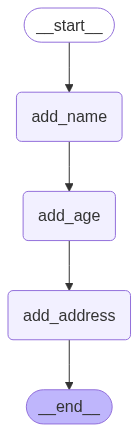

In [17]:
# 시각화
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
# 실행 
res = graph.invoke({})	# 첫 번째 node에 전달할 state를 dict로 전달.

add_name : {}
add_age : {'name': '홍박사'}
add_address : {'name': '홍박사', 'age': 35}


In [ ]:
###########################
# 상태(State) 클래스 정의
# node들이 공유할 state 값들을 정의하는 class(type)
class State(TypedDict):
    # state에 저장할 값(속성, state)들을 정의
    # messages : type 만 지정해 놓으면 그때마다 state값을 교체하면서 진행.
    messages : Annotated[list, add_messages]	# 변수 : Annotated[변수타입, 설명] 얘는 node 지날 때 마다 추가됨.
    
	# add_messages(left : list, right : list) : return [left + right]

In [17]:
model = ChatOpenAI(model="gpt-4.1-mini")
###################################################################
# Node def
# 노드 == 기능 == 함수(callable): parameter로 State 타입을 선언.
###################################################################
def chatbot(state:State):
    # state : Dictionary - key : State 클래스에 정의한 변수들.
    print("chatbot : state type :", type(state))
    
    # messages의 message 전체를 llm에 query로 전달
    response = model.invoke(state["messages"])
    
    # response를 state에 저장 -> dict로 구성, {저장할 state 이름 : 저장할 값}
    return {"messages" : response}	# return -> State에 저장.

In [8]:
START, END

('__start__', '__end__')

In [18]:
# graph 구성 (StateGraph)
## node, edge + state
workflow = StateGraph(State)

# graph(workflow)에 node 추가
workflow.add_node("chatbot", chatbot)	# .add_node(이름, 함수)

# graph(workflow)에 edge(node - node)를 구성.
## START node는 반드시 있어야 함. END node는 생략가능.
### START node - node - ... (- END node)
workflow.add_edge(START, "chatbot")		# .add_edge(시작 node 이름, 도착 node 이름), 하나의 연결만 표현 가능.
workflow.add_edge("chatbot", END)

# 구성을 완료하면 complie -> garph 최적화하고 실행할 수 있도록 하는 작업.
graph = workflow.compile()

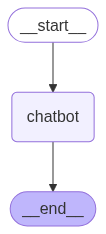

In [19]:
########################################
# graph 구조 시각화 -> 실행 흐름을 확인
########################################
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [11]:
!pip install gandalf

ERROR: For req: gandalf. Invalid script entry point: <ExportEntry gandalf = gandalf.console.cli:None []> - A callable suffix is required. Cf https://packaging.python.org/specifications/entry-points/#use-for-scripts for more information.


In [20]:
# 실행 - graph.invoke()

from langchain_core.messages import HumanMessage

query = "Langgraph에 대해서 알려줘."

init_state = {"messages" : [HumanMessage(content=query)]}
resp = graph.invoke(init_state)	# State에 넣어줄 초기값 -> 첫 번째 node가 사용

chatbot : state type : <class 'dict'>


In [27]:
resp

{'messages': [HumanMessage(content='Langgraph에 대해서 알려줘.', additional_kwargs={}, response_metadata={}, id='612bfb02-b28b-46ca-94ae-6c31a5a4e5f8'),
  AIMessage(content='Langgraph에 대해 알려드리겠습니다.\n\n**Langgraph**는 주로 자연어 처리(NLP)와 언어 모델 관련 분야에서 사용되는 개념 또는 툴일 가능성이 높으며, 이름에서 추측해볼 때 ‘Language’와 ‘Graph’를 결합한 용어로 보입니다. 하지만 2024년 6월 현재까지 일반적으로 널리 알려진 공식 제품명이나 특정 기술로서의 ‘Langgraph’는 존재하지 않는 것 같습니다.\n\n만약 사용자가 언급한 ‘Langgraph’가 특정 스타트업, 라이브러리, 프로젝트명, 또는 최근에 나온 기술이라면, 더 구체적인 정보(예: 발표처, 관련 분야, 링크 등)를 알려주시면 더욱 정확한 설명을 드릴 수 있습니다.\n\n---\n\n### 관련 가능성 있는 개념들\n\n1. **Language Graph (언어 그래프)**  \n   자연어 처리에서 ‘언어 그래프’는 단어, 문장, 개체(Entity), 개념 등을 노드로 하고 이들 사이의 관계를 엣지로 표현하는 그래프 구조를 말합니다.  \n   - 예: 지식 그래프(Knowledge Graph)  \n   - 활용: 의미 검색, 관계 추론, 질의응답 시스템 등에 쓰임\n\n2. **Graph-based NLP**  \n   최근 NLP에서는 텍스트 내 단어들 간의 관계를 그래프로 모델링하고, 이를 그래프 신경망(Graph Neural Networks)으로 처리하는 연구가 활발합니다. 이런 접근법에서 ‘Langgraph’라 부를 수 있는 프로젝트가 있을 수도 있습니다.\n\n---\n\n### 요약\n\n- 현재 ‘Langgraph’라는 이름의 특정 제품이나 기술에 대한 정보는 제한적임  \n- 자연어 처리에서 ‘언

In [28]:
print(resp["messages"][-1].content)

Langgraph에 대해 알려드리겠습니다.

**Langgraph**는 주로 자연어 처리(NLP)와 언어 모델 관련 분야에서 사용되는 개념 또는 툴일 가능성이 높으며, 이름에서 추측해볼 때 ‘Language’와 ‘Graph’를 결합한 용어로 보입니다. 하지만 2024년 6월 현재까지 일반적으로 널리 알려진 공식 제품명이나 특정 기술로서의 ‘Langgraph’는 존재하지 않는 것 같습니다.

만약 사용자가 언급한 ‘Langgraph’가 특정 스타트업, 라이브러리, 프로젝트명, 또는 최근에 나온 기술이라면, 더 구체적인 정보(예: 발표처, 관련 분야, 링크 등)를 알려주시면 더욱 정확한 설명을 드릴 수 있습니다.

---

### 관련 가능성 있는 개념들

1. **Language Graph (언어 그래프)**  
   자연어 처리에서 ‘언어 그래프’는 단어, 문장, 개체(Entity), 개념 등을 노드로 하고 이들 사이의 관계를 엣지로 표현하는 그래프 구조를 말합니다.  
   - 예: 지식 그래프(Knowledge Graph)  
   - 활용: 의미 검색, 관계 추론, 질의응답 시스템 등에 쓰임

2. **Graph-based NLP**  
   최근 NLP에서는 텍스트 내 단어들 간의 관계를 그래프로 모델링하고, 이를 그래프 신경망(Graph Neural Networks)으로 처리하는 연구가 활발합니다. 이런 접근법에서 ‘Langgraph’라 부를 수 있는 프로젝트가 있을 수도 있습니다.

---

### 요약

- 현재 ‘Langgraph’라는 이름의 특정 제품이나 기술에 대한 정보는 제한적임  
- 자연어 처리에서 ‘언어 그래프’ 개념과 연관 지어 이해 가능  
- 더 구체적 정보를 주시면 추가 설명 가능

필요하시면 언어 그래프 기술이나 그래프 기반 NLP 모델에 대해 자세히 설명해 드릴 수 있습니다!


# 4. 다양한 엣지

## **기본 엣지**

- 기본 엣지(Normal Edge)는 한 노드에서 다른 노드로의 직접적인 연결을 의미한다. 이는 가장 단순한 형태의 연결로, 이전 노드의 작업이 완료되면 자동으로 다음 노드로 이동한다.
- 기본 엣지는 다음과 같은 특징을 가진다:
  - **고정된 흐름**: 항상 동일한 다음 노드로 이동한다      
  - **단순한 구조**: 복잡한 조건 없이 순차적으로 실행된다      
  - **예측 가능한 동작**: 실행 전에 전체 흐름을 예측할 수 있다    

## **조건부 엣지와 라우팅**

- 조건부 엣지(Conditional Edge)는 특정 조건에 따라 다음에 실행할 노드를 동적으로 결정하는 기능이다. 이는 랭그래프의 ****가장 강력한 기능** 중 하나로, **복잡한 의사결정 로직**을 구현할 수 있게 한다.
- 조건부 엣지를 구현하기 위해서는 세 가지 구성 요소가 필요하다:
    - **1. 소스 노드(Source Node)**
      -  조건 평가가 시작될 노드의 이름이다.
    - **2. 조건 함수(Condition Function)**
      - 현재 상태를 입력받아 문자열을 반환하는 함수로, 다음에 실행할 노드를 결정하는 로직을 포함한다.
    - **3. 조건부 엣지 매핑(Conditional Edge Mapping)**
      -  조건 함수의 반환값과 다음 노드 이름을 매핑하는 딕셔너리이다.
```python
def relevance_check(state):     
    # 관련성 체크 로직    
    if state["relevance_score"] > 0.8:        
        return "grounded"    
    else:        
        return "not_grounded" 
        
graph.add_conditional_edges(
    "llm_answer",     # 소스 노드    
    relevance_check,  # 조건 함수    
    {        
        "grounded": END,  # 조건함수반환값:이동할 노드 (grounded 이면 END 노드로 이동)
        "not_grounded": "retrieve"  # not_grounded 이면 retrieve 노드로 이동
    } 
)
```

## **반복 구조**

- 랭그래프의 가장 큰 장점 중 하나는 반복 구조(순환 구조)를 지원한다는 점이다. 이를 통해 특정 조건이 만족될 때까지 작업을 반복하거나, 품질이 향상될 때까지 개선 과정을 반복할 수 있다.
- 반복 구조의 활용 예시:
  - **검색 품질 개선**
    - 검색 결과가 만족스럽지 않을 때 쿼리를 재작성하여 다시 검색한다      
  - **답변 품질 향상**
    - 생성된 답변의 품질이 낮을 때 다시 생성하거나 개선한다      
  - **할루시네이션 방지**
    -  답변이 검색된 문서와 관련성이 낮을 때 재생성을 요청한다

In [42]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tools = ([tool])
tool_model = ChatOpenAI(model="gpt-4.1").bind_tools(tools)
tool_model

RunnableBinding(bound=ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000230FFDD55B0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000230FFDD5820>, root_client=<openai.OpenAI object at 0x00000230FFBDE090>, root_async_client=<openai.AsyncOpenAI object at 0x00000230FFDD5730>, model_name='gpt-4.1', model_kwargs={}, openai_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 't

In [ ]:
class State(TypedDict):
    messages : Annotated[list, add_messages]
    # add_messages(func) : 상태 값을 저장하는 방법을 정의한 func -> reducer
    
# node def
def chatbot(state:State):
    response = tool_model.invoke(state["messages"])
    return {"messages" : [response]}

class CustomToolNode:
    def __init__(self, tools): # Tool List를 받는다.
        # 속성으로 툴이름 저장
        self.tools_by_name = {tool.name: tool for tool in tools}  # dict[tool이름:Tool객체]

    def __call__(self, inputs:State):  # inputs: State
        if messages := inputs.get("messages", []):
            message = messages[-1]  # tool calls가 있는 AI Message  (messages는 메세지들이 누적되어 있으므로 마지막 Message 객체를 가져온다.)
        else:
            raise ValueError("No messages found in inputs.")

        outputs = []
        for tool_call in message.tool_calls:
            tool_message = self.tools_by_name[tool_call['name']].invoke(tool_call)
            outputs.append(tool_message)

        return {"messages": outputs}
    
tool_node = CustomToolNode(tools)

## Tool들을 호출하는 Prebulit Node
from langgraph.prebuilt import ToolNode		# == CustomToolNode
tool_node = ToolNode(tools)


#################################
# 조건부 엣지 함수
# 조건에 따라 실행할 다음 node의 이름/식별자를 반환.

def custom_tools_condition(state:State):
    if messages := state.get("messages" , []):
        ai_message = messages[-1]
    else:
        raise Exception("State에 message가 없습니다용")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        # AIMessage -> tool_calls가 있고, tool_calls에 한 개 이상의 tool_call 값이 있따면
        return "tools"	# 다음 node의 이름 반환
    else:
        return END	# "__end__"
    
from langgraph.prebuilt import tools_condition	# == custom_tools_condition
# add_conditional_edge()에 이 함수를 넣으면 됨.

### 객체의 특정 attribute
- `hasattr()` : 가 있는지 여부
- `getattr()` : 의 값을 조회
- `setattr()` : 의 값을 할당
	- 문자열로 instance 변수들을 다룰 수 있는 것이 장점.

In [45]:
t = CustomToolNode(tools)
hasattr(t, "tools_by_name"), hasattr(t, "tools_name")
# getattr(t, "tools_by_name")
# setattr(t, "name", "툴실행 노드")

(True, False)

In [ ]:
# Graph def
workflow = StateGraph(State)

# node add
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", tool_node)

# node 연결 --> edge	# 그림 연상
workflow.add_edge(START, "chatbot")
workflow.add_conditional_edges("chatbot", 
                               custom_tools_condition,	# == tools_condition
                               {"tools" : "tools", END : END})
workflow.add_edge("tools", "chatbot")

graph = workflow.compile()

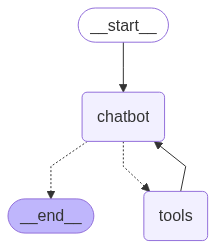

In [55]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [ ]:
query = "Langgraph가 무엇인지 설명해줘. 검색을해서 정확한 정보를 알려줘."
init_state = {"messages" : [HumanMessage(content=query)]}
response = graph.invoke(init_state)
# print(response)

In [64]:
print(response["messages"][-1].content)

Langgraph는 대규모 언어 모델(LLM, 예: OpenAI API 등)을 활용한 AI 워크플로우를 시각적으로 설계하고 관리할 수 있게 해주는 프레임워크입니다. 주요 특징은 다음과 같습니다.

- 그래프(노드-엣지 구조) 기반: 각 작업 단위를 노드(Node)로 표현하고, 데이터의 흐름은 엣지(Edge)로 연결하여 전체 워크플로우를 시각화합니다.
- 복잡한 데이터 흐름과 다단계 LLM 작업 구현: 여러 단계를 거치는 AI 작업(예: 질문 이해하기 → 정보 검색 → 답변 생성 등)을 쉽게 설계할 수 있습니다.
- 조건 분기 가능: 조건에 따라 워크플로우를 분기하거나, 다양한 논리를 포함해 복잡한 의사결정 구조도 만들 수 있습니다.
- 다양한 LLM 통합: OpenAI API 등을 활용하여 LLM 기반 프롬프트 생성, 응답 처리 자동화가 가능합니다.

실제 예시로, “사용자 질문 → 의도 파악 → 필요 정보 검색 → 답변 작성 → 결과 전달” 같은 챗봇, 상담 시스템, 또는 복잡한 AI 자동화 파이프라인을 만들 때 유용하게 활용할 수 있습니다.

좀 더 자세한 설명과 예시는 아래 링크에서 확인하실 수 있습니다.
- 벨로그 LangGraph 소개: 벨로그 글 보기
- 초보자용 LangGraph 안내: 티스토리 가이드 보기

요약: Langgraph는 LLM과 워크플로우 자동화 및 시각적 설계를 위한 프레임워크로, 복잡한 AI 업무를 효율적으로 구현하는 데 사용됩니다.


# 5. 랭그래프에서 메모리 관리

랭그래프에서 메모리 관리는 **체크포인터(Checkpointer)** 기능을 통해 구현된다. 이는 복잡한 대화형 AI 시스템 구축에 필수적인 기능으로, 상태를 저장하고 관리하는 핵심 역할을 한다.

- **체크포인터의 주요 기능:**
    - **1. 상태 지속성**
      -  그래프 실행 중간에 상태를 저장하여 나중에 복원할 수 있다.
    - **2. 대화 기록 유지**
      - 이전 대화 내용을 기억하여 연속적인 대화가 가능하다.
    - **3. 오류 복구**
      -  실행 중 오류가 발생했을 때 이전 상태로 돌아갈 수 있다.
-   구현
    -  Graph를 컴파일할 때 checkpointer객체를 설정한다.
    - Graph 실행시 대화를 저장할 때 사용할 thread_id를 `RunnableConfig`를 이용해 전달한다.

```python

from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

# 메모리 체크포인터 생성
checkpointer = MemorySaver()
# SQLite 체크포인터 생성
# checkpointer = SqliteSaver.from_conn_string("checkpoints.db")

# 그래프에 연결
graph = workflow.compile(checkpointer=checkpointer)

# graph 호출시 thread_id 전달
config = {"configurable": {"thread_id": "user-123"}}
response = graph.invoke({"messages": [user_message]}, config)
```

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from dotenv import load_dotenv
from typing_extensions import TypedDict


from tools import search_web

load_dotenv()

True

In [23]:
from typing import Annotated
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [42]:
# node def
from datetime import date
from re import search
from textwrap import dedent
class ChatbotNode:
    def __init__(self, tools):
        prompt = ChatPromptTemplate(
            [
                ("system", dedent("""
                    당신은 다양한 지식을 제공하는 AI 어시스턴트입니다. 
                    주요 목표는 사용자의 요청에 대한 정확한 정보를 이해하기 쉽게 설명하는 것입니다.

					Instruction:
					정확한 답변을 위해 웹 검색이 필요하거나 최신 정보를 얻고 싶을 때는 search_web 도구를 사용하십시오. 이 도구는 인터넷 검색을 통해 정보를 검색해서 제공합니다.
					최신 정보를 제공해야 할 때는 {today} 를 기준으로 합니다.
					검색 결과를 기반으로 명확하고 간결한 답변을 제공하십시오.
					최종 응답은 챗봇과 같은 대화형 스타일을 유지하세요. 친근하고 쉽고 자연스럽게 다변하되 전문성을 보이는 어조를 유지하세요.

                    각 도구들을 결합해서 사용자의 요청에 정확한 대답을 하세요.
                    항상 가장 최신의 정확한 정보를 제공하기 위해 노력하세요.
                    """)),
                ("human", "{query}")
            ],
            partial_variables={"today": date.today().strftime('%Y년 %m월 %d일')}
        )
        tool_model = ChatOpenAI(model="gpt-4.1").bind_tools(tools)
        self.chain = prompt | tool_model
        
    def __call__(self, input_state:State):
        response = self.chain.invoke({"query" : input_state["messages"]})
        return {"messages" : [response]}
    
tools = [search_web]
chatbot_node = ChatbotNode(tools)


In [43]:
# tool 호출 처리 node
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools) 	# 위 예재의 CustomToolNode와 동일한 역할

In [44]:
from langgraph.prebuilt import tools_condition # custom_tools_condition func와 동일한 역할
# graph 구성
workflow = StateGraph(State)

# add node
workflow.add_node("chatbot", chatbot_node)
workflow.add_node("tools", tool_node)

# edge 연결
workflow.add_edge(START, "chatbot")
# chatbot - tool_calls 여부에 따라 -> END | tool_node (분기 -> add_conditional_edge() 사용)
workflow.add_conditional_edges("chatbot", tools_condition, {"tools" : "tools", END : END})
workflow.add_edge("tools", "chatbot")	# chatbot <-> tools

In [45]:
# graph complie + checkpointer 설정 : 대화내역 저장 관리.
checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)

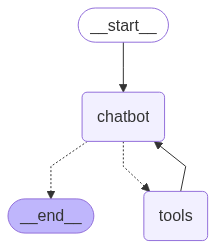

In [35]:
# 시각화
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [46]:
# 호출(invoke) -> 대화 ID를 config로 전달
config = {"configurable" : {"thread_id" : "user-1"}}
user_input = "내 이름은 홍박사입니다."
init_state = {"messages" : [HumanMessage(content= user_input)]}
response = graph.invoke(init_state, config= config)

In [47]:
response

{'messages': [HumanMessage(content='내 이름은 홍박사입니다.', additional_kwargs={}, response_metadata={}, id='e89ecbe9-1275-47cd-bb89-899aded328aa'),
  AIMessage(content='안녕하세요, 홍박사님! 무엇을 도와드릴까요? 궁금하신 점이나 필요하신 정보가 있으시면 언제든 말씀해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 344, 'total_tokens': 380, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-BlRKGdDljpHuWxGgFrIEyK7r0Bpkx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--319fcad4-7784-4d13-825a-8b3345229e1c-0', usage_metadata={'input_tokens': 344, 'output_tokens': 36, 'total_tokens': 380, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}

In [48]:
response2 = graph.invoke(
    {"messages" : "내 이름의 한국 고전 소설이 있는지 확인해줘. 있으면 소개도 부탁해용"},
    config=config
)

In [49]:
response2

{'messages': [HumanMessage(content='내 이름은 홍박사입니다.', additional_kwargs={}, response_metadata={}, id='e89ecbe9-1275-47cd-bb89-899aded328aa'),
  AIMessage(content='안녕하세요, 홍박사님! 무엇을 도와드릴까요? 궁금하신 점이나 필요하신 정보가 있으시면 언제든 말씀해 주세요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 344, 'total_tokens': 380, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-BlRKGdDljpHuWxGgFrIEyK7r0Bpkx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--319fcad4-7784-4d13-825a-8b3345229e1c-0', usage_metadata={'input_tokens': 344, 'output_tokens': 36, 'total_tokens': 380, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}

In [51]:
config2 = {"configurable" : {"thread_id" : "test-111"}}

res = graph.invoke({"messages" : "내 이름 기억하니 "}, config=config2)

In [52]:
res

{'messages': [HumanMessage(content='내 이름 기억하니 ', additional_kwargs={}, response_metadata={}, id='308ac422-3b52-4459-a392-dedc81e8aabc'),
  AIMessage(content='아직 당신의 이름을 알려주지 않으셨어요! 이름을 말씀해주시면 기억해서 대화에 활용할게요. 알려주실래요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 343, 'total_tokens': 381, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_51e1070cf2', 'id': 'chatcmpl-BlRP7MCKrEFDsg1gY0M0ES5vaT0CN', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--260d5afe-cf9d-4d86-83a7-f15c2e821c8e-0', usage_metadata={'input_tokens': 343, 'output_tokens': 38, 'total_tokens': 381, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}